# Tutorial: Agent Comparison

This notebook shows how to recover previously trained RL agents from the registry and compare them against two MPC configurations on a common scenario.


## Objective

Compare, for one SKU, the performance of two MPC configurations and two previously trained RL agents.

The final comparison uses violin plots for four policies in total.


In [18]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
ROOT = next((candidate for candidate in CANDIDATES if (candidate / 'control_rl').exists()), None)
if ROOT is None:
    raise RuntimeError('Could not locate repo root containing control_rl')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pyomo.environ import SolverFactory
from model.demand import DemandDistribution
from model.evaluation import build_scenario, evaluate_policy
from control_mpc.mpc_policy import MPCPolicy
from control_rl.agents import get_sku_config, list_registered_agents, load_policy


## API Used

- `get_sku_config(...)`: retrieves the SKU configuration from the registry.
- `list_registered_agents(...)`: lists persisted agents for one SKU.
- `load_policy(...)`: loads a registered RL agent and returns it ready for evaluation.
- `build_scenario(...)`: builds common demand, lead times, and initial inventories.
- `evaluate_policy(...)`: runs a policy on the scenario and returns per-replica KPIs.
- `MPCPolicy(...)`: creates an MPC policy that also exposes `compute_action(...)`.


In [19]:
SKU_ID = 'sku_001'
REGISTRY_ROOT = ROOT / 'artifacts' / 'sku_registry'
OUTPUT_DIR = ROOT / 'artifacts' / 'trained_models' / SKU_ID / 'comparison'

R = 20
N_DAYS = 30
SEED = 123
KPI_LIST = ['total_cost', 'total_lost_sales', 'avg_inventory']


## Recover the SKU and the RL Agents

We follow the same criterion as the script: take the first two RL agents registered for the SKU.


In [20]:
env_config = get_sku_config(REGISTRY_ROOT, SKU_ID)
registered_agents = list_registered_agents(REGISTRY_ROOT, SKU_ID)
if len(registered_agents) < 3:
    raise RuntimeError(f"SKU '{SKU_ID}' must have at least two registered agents to compare")

selected_agents = registered_agents[:3]
pd.DataFrame([
    {
        'agent_id': agent['agent_id'],
        'algorithm_name': agent['algorithm_name'],
        'algorithm_config_key': agent['algorithm_config_key'],
    }
    for agent in selected_agents
])


,agent_id,algorithm_name,algorithm_config_key
0,dqn_171964e8,DQN,171964e8
1,ppo_16dc9d30,PPO,16dc9d30
2,sac_c62a2e37,SAC,c62a2e37


In [21]:
loaded_agents = []
for agent in selected_agents:
    loaded_agent = load_policy(
        registry=REGISTRY_ROOT,
        sku_id=SKU_ID,
        agent_id=str(agent['agent_id']),
        include_metadata=True,
    )
    loaded_agents.append(loaded_agent)

[(agent['model_name'], agent['agent_metadata']['algorithm_name']) for agent in loaded_agents]


[('DQN:dqn_171964e8', 'DQN'),
 ('PPO:ppo_16dc9d30', 'PPO'),
 ('SAC:sac_c62a2e37', 'SAC')]

## Common Evaluation Scenario

The same scenario is reused for RL and MPC. That makes the comparison direct.


In [22]:
scenario = build_scenario(
    R=R,
    N_days=N_DAYS,
    env_config=env_config,
    base_seed=SEED,
)


## MPC Configurations

We take two configurations from the `mpc_experiments.ipynb` notebook and build one policy for each of them.


In [23]:
preferred_solver = 'highs'
solver_fallback = ['cbc', 'gurobi']

def pick_solver(preferred: str, fallback: list[str]) -> str:
    for name in [preferred, *fallback]:
        try:
            solver = SolverFactory(name)
            if solver.available(False):
                return name
        except Exception:
            pass
    raise RuntimeError('No Pyomo solver available for MPC evaluation')

solver_name = pick_solver(preferred_solver, solver_fallback)
solver_name


'highs'

In [27]:
demand_model = DemandDistribution(env_config['demand_spec'])
d_low, d_high = demand_model.bounds()
policy_demand_generator = demand_model.sample

base_params = {
    'Lmax': int(env_config['Lmax']),
    'K_fix': float(env_config['K_fix']),
    'v': float(env_config['v']),
    'h': float(env_config['h']),
    'p': float(env_config['p']),
    'lambda': 0.5,
    'q_min': float(env_config['q_min']),
    'q_max': float(env_config['q_max']),
    'scenario_demand_low': float(d_low),
    'scenario_demand_high': float(d_high),
    'scenario_lead_time_weights': [float(x) for x in env_config['lead_time_weights']],
}

mpc_configs = [
    {'H': 4, 'Ns': 20, 'I_target': 20},
    {'H': 8, 'Ns': 20, 'I_target': 20},
]

def make_mpc_name(config: dict[str, float | int]) -> str:
    return f"MPC (H = {int(config['H'])})"

mpc_policies = []
for index, config in enumerate(mpc_configs):
    params = dict(base_params)
    params.update(config)
    policy = MPCPolicy(
        params=params,
        solver_name=solver_name,
        scenario_seed=SEED + 200_000 + index,
        demand_generator=policy_demand_generator,
    )
    mpc_policies.append({
        'model_name': make_mpc_name(config),
        'policy': policy,
        'config': config,
    })

pd.DataFrame([
    {'model_name': item['model_name'], **item['config']}
    for item in mpc_policies
])


,model_name,H,Ns,I_target
0,MPC (H = 4),4,20,20
1,MPC (H = 8),8,20,20


## Evaluate Policies

We first evaluate the RL policies recovered from the registry and then the two MPC policies.


In [28]:
labels = []
result_frames = []
aggregate_rows = []

for loaded_agent in loaded_agents:
    model_name = str(loaded_agent['model_name'])
    policy = loaded_agent['policy']
    result = evaluate_policy(
        model_name=model_name,
        policy=policy,
        scenario=scenario,
        env_config=env_config,
    )
    labels.append(model_name)
    result_frames.append(result['kpi_summary'].assign(agent_label=model_name))
    aggregate_rows.append({'model_name': model_name, **result['aggregate_summary']})

for mpc_item in mpc_policies:
    model_name = str(mpc_item['model_name'])
    policy = mpc_item['policy']
    result = evaluate_policy(
        model_name=model_name,
        policy=policy,
        scenario=scenario,
        env_config=env_config,
    )
    labels.append(model_name)
    result_frames.append(result['kpi_summary'].assign(agent_label=model_name))
    aggregate_rows.append({'model_name': model_name, **result['aggregate_summary']})

compare_df = pd.concat(result_frames, ignore_index=True)
aggregate_df = pd.DataFrame(aggregate_rows)
aggregate_df


,model_name,n_replicas,replica_mean,total_cost_mean,ordering_cost_mean,holding_cost_mean,lost_sales_cost_mean,fill_rate_mean,total_lost_sales_mean,avg_inventory_mean,n_orders_mean,stockout_count_mean,n_days_mean
0,DQN:dqn_171964e8,20,9.5,409.414700,237.100000,100.521778,71.792922,0.953289,11.965487,22.338173,5.55,2.40,30.0
1,PPO:ppo_16dc9d30,20,9.5,577.444345,274.450000,94.052860,208.941485,0.863997,34.823581,20.900636,14.05,5.95,30.0
2,SAC:sac_c62a2e37,20,9.5,546.639767,441.929496,96.499911,8.210359,0.994871,1.368393,21.444425,30.00,0.55,30.0
3,MPC (H = 4),20,9.5,465.233395,357.070611,96.080721,12.082062,0.992127,2.013677,21.351271,19.20,0.65,30.0
4,MPC (H = 8),20,9.5,400.542251,275.398936,105.898560,19.244755,0.987667,3.207459,23.533013,8.80,1.10,30.0


## Final Violin Plots

The final figure compares all the algorithms: the RL agents loaded from the registry and two MPC policies.


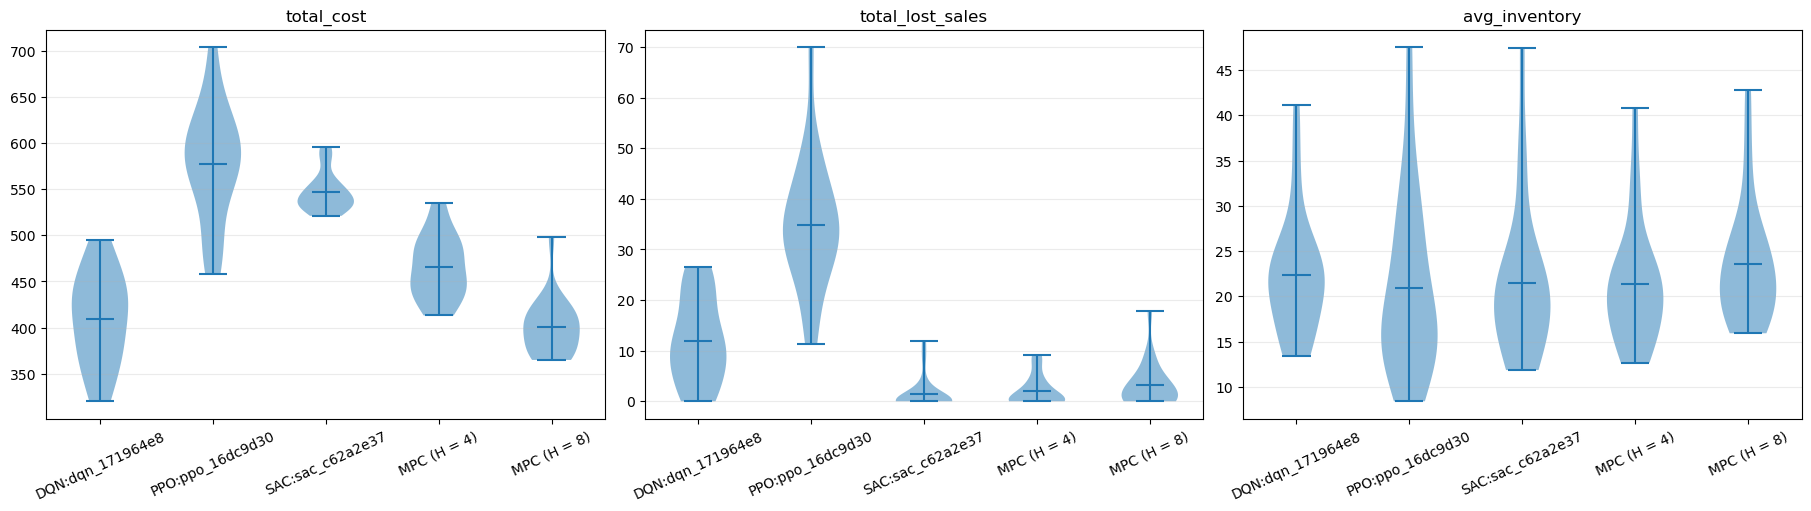

In [29]:
fig, axes = plt.subplots(1, len(KPI_LIST), figsize=(6 * len(KPI_LIST), 5), constrained_layout=True)
if len(KPI_LIST) == 1:
    axes = [axes]

for ax, kpi in zip(axes, KPI_LIST):
    data = [
        compare_df.loc[compare_df['agent_label'] == label, kpi].to_numpy(dtype=float)
        for label in labels
    ]
    parts = ax.violinplot(data, showmeans=True, showextrema=True)
    for body in parts['bodies']:
        body.set_alpha(0.5)
    ax.set_xticks(range(1, len(labels) + 1), labels)
    ax.tick_params(axis='x', rotation=25)
    ax.set_title(kpi)
    ax.grid(axis='y', alpha=0.25)

plt.show()


## Result

This notebook leaves a homogeneous comparison between already persisted RL agents and two MPC policies with different configurations, all evaluated on the same scenario.
